In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt

In [7]:
data_log_offline = pd.read_csv("data_log_offline.csv")
data_log_online = pd.read_csv("data_log_online.csv")

In [8]:
data_log_online

,time,t,btc_price,btc_volume,BTCUSDT_Close,BTCUSDT_beta,BTCUSDT_beta_adj,BTCUSDT_corr,BTCUSDT_residual,BTCUSDT_residual_z,...,residual_mean,residual_std,residual_z_all,residual_z_selected,residual_sign,corr_all,corr_selected,coef_adj_all,coef_adj_selected,y_pred
0,2026-02-17T15:39:42.034643+0000,0,66765.7,121.260,66800.2,1.000014,1.000014,1.000000,0.000502,25,...,-0.000491,0.002371,11.302326,16.5,6.5,0.999997,0.999992,1.001014,0.999382,-27.572149
1,2026-02-17T15:40:42.034645+0000,1,66857.0,102.129,66852.7,1.000012,1.000012,1.000000,-0.000076,17,...,0.000081,0.002314,17.604651,17.0,4.5,0.999997,0.999990,0.999860,0.998168,-27.620173
2,2026-02-17T15:41:42.034660+0000,2,66826.9,127.690,66824.6,1.000011,1.000011,1.000000,-0.000045,21,...,0.000574,0.002361,20.767442,19.0,6.5,0.999997,0.999989,0.999397,0.997816,-27.611037
3,2026-02-17T15:42:42.034693+0000,3,66832.3,50.537,66832.3,1.000010,1.000010,1.000000,-0.000010,20,...,-0.000007,0.002451,17.558140,17.5,3.5,0.999997,0.999992,1.000013,0.997690,-27.508228
4,2026-02-17T15:43:42.034534+0000,4,66883.4,93.324,66872.7,1.000005,1.000005,1.000000,-0.000165,15,...,-0.000201,0.002544,17.139535,19.5,6.5,0.999997,0.999987,1.000047,0.997077,-27.516451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,2026-02-18T11:06:54.510112+0000,1165,67693.1,125.065,67693.1,1.000003,1.000003,0.999671,-0.000003,120,...,-0.000730,0.005118,61.232558,56.5,0.5,0.713626,0.668153,1.000757,1.013363,-25.036843
1166,2026-02-18T11:07:54.510144+0000,1166,67481.3,867.650,67481.3,1.000003,1.000003,0.999699,-0.000003,120,...,0.000742,0.004978,83.767442,68.0,10.5,0.727333,0.812758,0.999283,1.010032,-27.396511
1167,2026-02-18T11:09:03.271940+0000,1167,67263.1,1202.319,67263.1,1.000003,1.000003,0.999742,-0.000003,120,...,-0.001484,0.005554,50.488372,61.5,5.5,0.761427,0.803930,1.001517,1.010577,-27.573925
1168,2026-02-18T11:09:54.510118+0000,1168,67118.1,1174.902,67118.1,1.000003,1.000003,0.999784,-0.000003,120,...,0.000363,0.005035,74.744186,69.5,6.5,0.789703,0.790205,0.999662,1.006318,-27.257862


In [9]:
data_log_offline.set_index("time", inplace=True)
data_log_offline.index = pd.to_datetime(data_log_offline.index)

data_log_online.set_index("time", inplace=True)
data_log_online.index = pd.to_datetime(data_log_online.index)

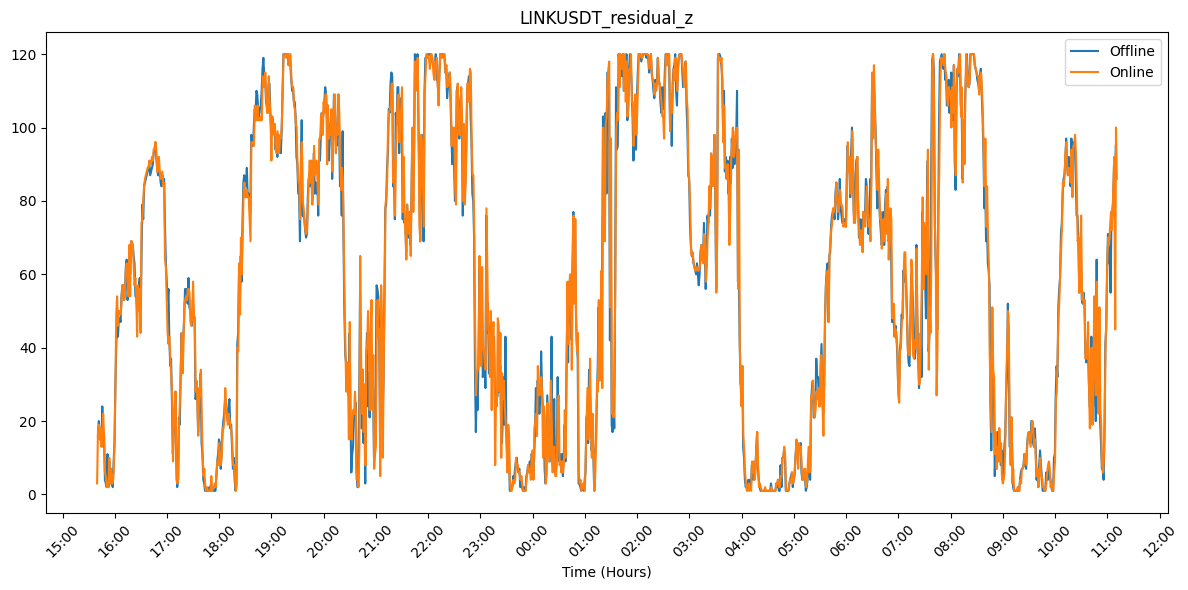

In [135]:
random_col = data_log_offline.columns[random.randint(0, len(data_log_offline.columns) - 1)]
plt.figure(figsize=(12, 6))
plt.plot(data_log_offline[random_col], label='Offline')
plt.plot(data_log_online[random_col], label='Online')
plt.legend()
plt.title(random_col)

# 设置x轴为时间索引，显示整数小时
plt.xlabel('Time (Hours)')
plt.xticks(rotation=45)

# 如果需要更精确的小时间隔控制，可以使用以下代码
import matplotlib.dates as mdates
if pd.api.types.is_datetime64_any_dtype(data_log_offline.index):
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:00'))

plt.tight_layout()
plt.show()